<a href="https://colab.research.google.com/github/randyliu078-bit/qss20-final-project/blob/main/code/03_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

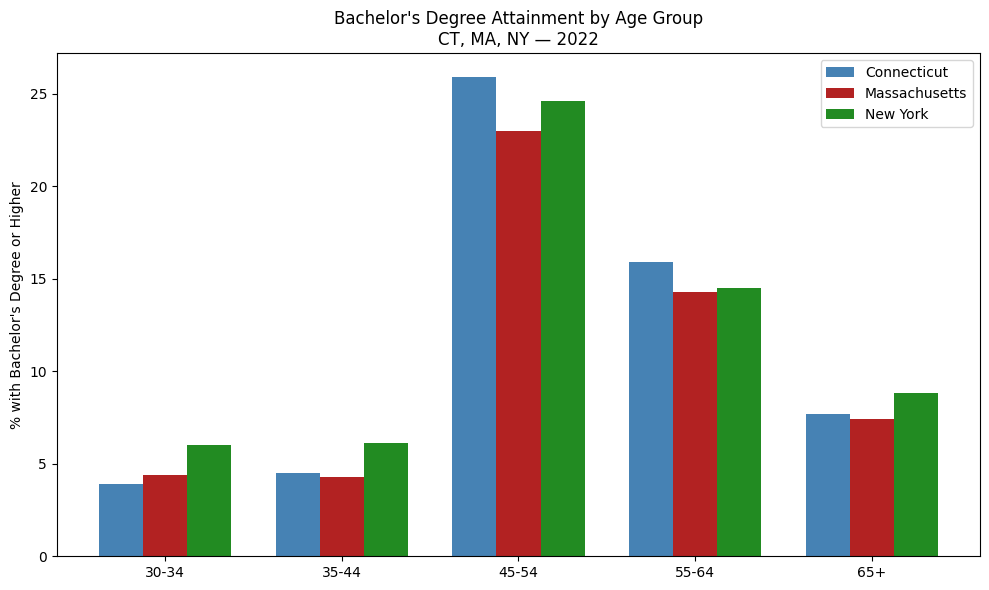

In [16]:
# ============================================================
# 03_analysis.ipynb — QSS 20 Final Project — Randy Liu
# Visualizations and analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import requests
import io

API_KEY = "84be3d1f35c778150bb57bc7f815f88136459eac"

# ---- Re-pull ACS data ----
acs_url = "https://api.census.gov/data/2022/acs/acs1/subject?get=NAME,S1501_C02_006E,S1501_C02_007E,S1501_C02_008E,S1501_C02_009E,S1501_C02_010E,S1501_C02_011E&for=state:09,25,36&key=" + API_KEY
data = requests.get(acs_url).json()
acs_df = pd.DataFrame(data[1:], columns=data[0])
acs_df.columns = ["state_name","age_25_29","age_30_34","age_35_44","age_45_54","age_55_64","age_65plus","state_fips"]
acs_df = acs_df.replace("-888888888", None)
for col in ["age_30_34","age_35_44","age_45_54","age_55_64","age_65plus"]:
    acs_df[col] = pd.to_numeric(acs_df[col])

# ---- Figure 1: Bachelor's degree attainment by age group ----
age_groups = ["age_30_34","age_35_44","age_45_54","age_55_64","age_65plus"]
labels = ["30-34","35-44","45-54","55-64","65+"]
colors = {"Connecticut":"steelblue","Massachusetts":"firebrick","New York":"forestgreen"}

x = range(len(age_groups))
width = 0.25
fig, ax = plt.subplots(figsize=(10,6))

for i, (_, row) in enumerate(acs_df.iterrows()):
    vals = [pd.to_numeric(row[col]) for col in age_groups]
    ax.bar([xi + i*width for xi in x], vals, width, label=row["state_name"],
           color=list(colors.values())[i])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels)
ax.set_ylabel("% with Bachelor's Degree or Higher")
ax.set_title("Bachelor's Degree Attainment by Age Group\nCT, MA, NY — 2022")
ax.legend()
plt.tight_layout()
plt.savefig("fig1_degree_attainment.png", dpi=150)
plt.show()


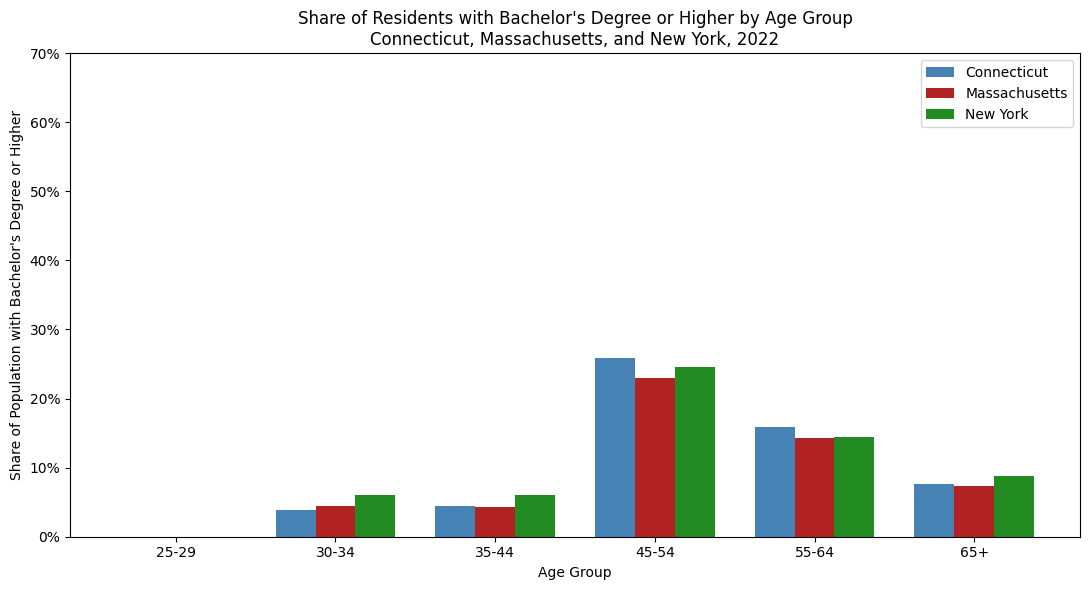

In [17]:
# ---- Figure 1: Bachelor's degree attainment by age group (styled like Milestone 1) ----
age_groups = ["age_25_29","age_30_34","age_35_44","age_45_54","age_55_64","age_65plus"]
labels = ["25-29","30-34","35-44","45-54","55-64","65+"]

# Re-pull with age_25_29 included
data = requests.get(acs_url).json()
acs_df2 = pd.DataFrame(data[1:], columns=data[0])
acs_df2.columns = ["state_name","age_25_29","age_30_34","age_35_44","age_45_54","age_55_64","age_65plus","state_fips"]
for col in age_groups:
    acs_df2[col] = pd.to_numeric(acs_df2[col], errors="coerce")

fig, ax = plt.subplots(figsize=(11,6))
x = range(len(age_groups))
width = 0.25
colors = ["steelblue","firebrick","forestgreen"]

for i, (_, row) in enumerate(acs_df2.iterrows()):
    vals = [row[col] for col in age_groups]
    ax.bar([xi + i*width for xi in x], vals, width,
           label=row["state_name"], color=colors[i])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels)
ax.set_xlabel("Age Group")
ax.set_ylabel("Share of Population with Bachelor's Degree or Higher")
ax.set_title("Share of Residents with Bachelor's Degree or Higher by Age Group\nConnecticut, Massachusetts, and New York, 2022")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.legend(loc="upper right")
ax.set_ylim(0, 70)
plt.tight_layout()
plt.savefig("fig1_degree_attainment.png", dpi=150)
plt.show()


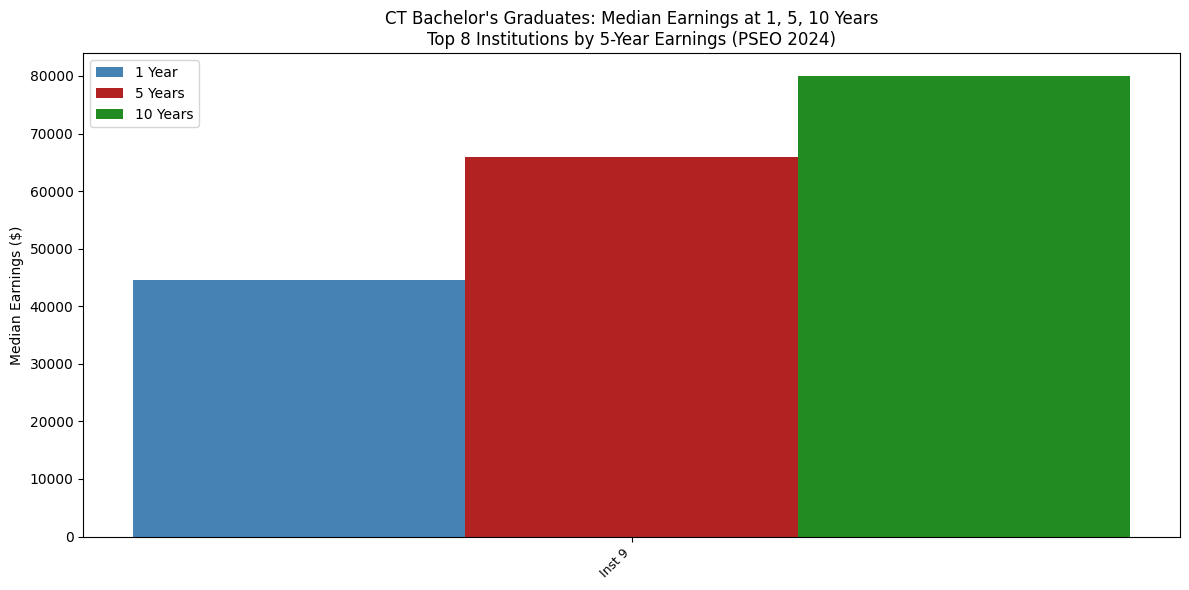

In [18]:
# ---- Figure 2: PSEO median earnings at 1, 5, 10 years ----
pseo_df = pd.read_csv(io.BytesIO(requests.get(
    "https://lehd.ces.census.gov/data/pseo/R2024Q4/ct/pseoe_ct.csv.gz"
).content), compression="gzip", low_memory=False)

pseo_bach = pseo_df[
    (pseo_df["degree_level"] == 5) &
    (pseo_df["agg_level_pseo"] == 26) &
    (pseo_df["geo_level"] == "N") &
    (pseo_df["ind_level"] == "A")
].copy()

pseo_bach = pseo_bach.dropna(subset=["y1_p50_earnings","y5_p50_earnings","y10_p50_earnings"])
top = pseo_bach.nlargest(8, "y5_p50_earnings").reset_index(drop=True)

# Use institution code as label since names may be numeric
inst_labels = [f"Inst {row['institution']}" for _, row in top.iterrows()]

x = range(len(top))
width = 0.25
fig, ax = plt.subplots(figsize=(12,6))
ax.bar([i-0.25 for i in x], top["y1_p50_earnings"], width, label="1 Year", color="steelblue")
ax.bar([i      for i in x], top["y5_p50_earnings"],  width, label="5 Years", color="firebrick")
ax.bar([i+0.25 for i in x], top["y10_p50_earnings"], width, label="10 Years", color="forestgreen")

ax.set_xticks(list(x))
ax.set_xticklabels(inst_labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Median Earnings ($)")
ax.set_title("CT Bachelor's Graduates: Median Earnings at 1, 5, 10 Years\nTop 8 Institutions by 5-Year Earnings (PSEO 2024)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_pseo_earnings.png", dpi=150)
plt.show()


In [19]:
# Diagnose what's in the filtered data
print("Rows after filter:", pseo_bach.shape[0])
print("Top rows:")
print(top[["institution","y1_p50_earnings","y5_p50_earnings","y10_p50_earnings"]])

Rows after filter: 1
Top rows:
   institution  y1_p50_earnings  y5_p50_earnings  y10_p50_earnings
0            9          44577.0          65860.0           79970.0


In [20]:
# ---- Figure 2 fixed: loosen filter to get more institutions ----
pseo_bach2 = pseo_df[
    (pseo_df["degree_level"] == 5) &
    (pseo_df["geo_level"] == "N") &
    (pseo_df["ind_level"] == "A")
].copy()

pseo_bach2 = pseo_bach2.dropna(subset=["y1_p50_earnings","y5_p50_earnings","y10_p50_earnings"])
print("Rows after looser filter:", pseo_bach2.shape[0])
print(pseo_bach2[["institution","agg_level_pseo","y1_p50_earnings","y5_p50_earnings"]].head(10))


Rows after looser filter: 1828
    institution  agg_level_pseo  y1_p50_earnings  y5_p50_earnings
4             9              26          44577.0          65860.0
10            9              28          37773.0          64700.0
16            9              28          34381.0          58372.0
19            9              28          44584.0          66693.0
24            9              28          40492.0          53667.0
29            9              28          38815.0          60593.0
39            9              28          63131.0          88083.0
47            9              28          37905.0          61488.0
53            9              28          71880.0          93407.0
59            9              28          59651.0          82038.0


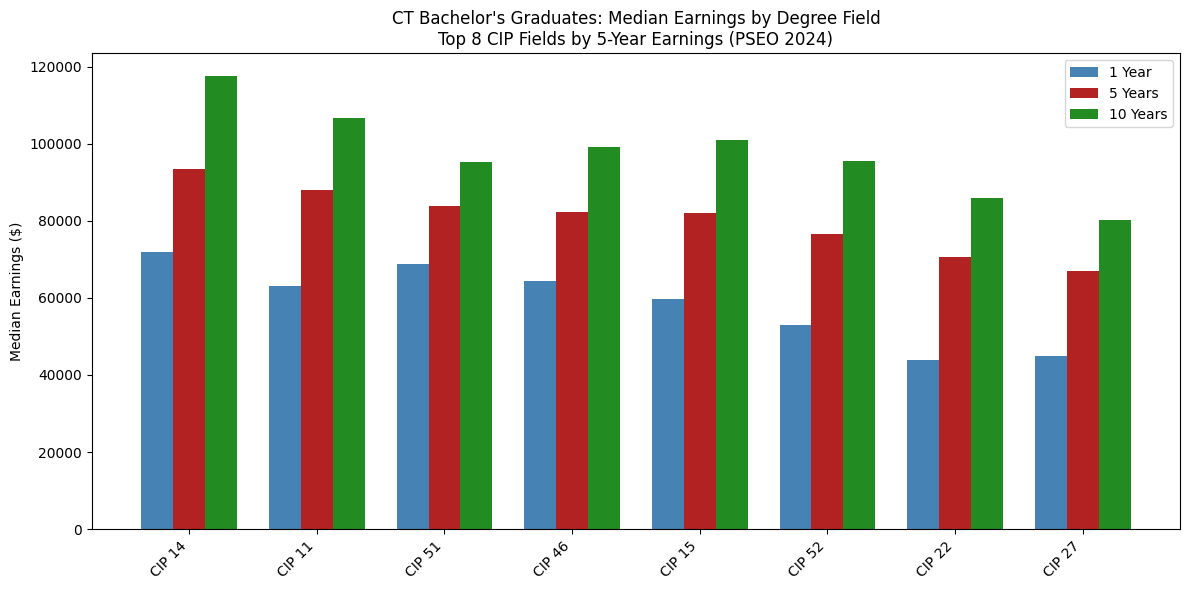

In [21]:
# ---- Figure 2: Median earnings by CIP field for CT bachelor's grads ----
# Use agg_level 28 (institution x cipcode level), filter to top fields by 5yr earnings
top_fields = pseo_bach2[pseo_bach2["agg_level_pseo"] == 28].groupby("cipcode")[["y1_p50_earnings","y5_p50_earnings","y10_p50_earnings"]].mean()
top_fields = top_fields.dropna().nlargest(8, "y5_p50_earnings").reset_index()

cip_labels = [f"CIP {int(c)}" for c in top_fields["cipcode"]]
x = range(len(top_fields))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))
ax.bar([i-0.25 for i in x], top_fields["y1_p50_earnings"], width, label="1 Year", color="steelblue")
ax.bar([i      for i in x], top_fields["y5_p50_earnings"],  width, label="5 Years", color="firebrick")
ax.bar([i+0.25 for i in x], top_fields["y10_p50_earnings"], width, label="10 Years", color="forestgreen")

ax.set_xticks(list(x))
ax.set_xticklabels(cip_labels, rotation=45, ha="right")
ax.set_ylabel("Median Earnings ($)")
ax.set_title("CT Bachelor's Graduates: Median Earnings by Degree Field\nTop 8 CIP Fields by 5-Year Earnings (PSEO 2024)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_pseo_earnings.png", dpi=150)
plt.show()


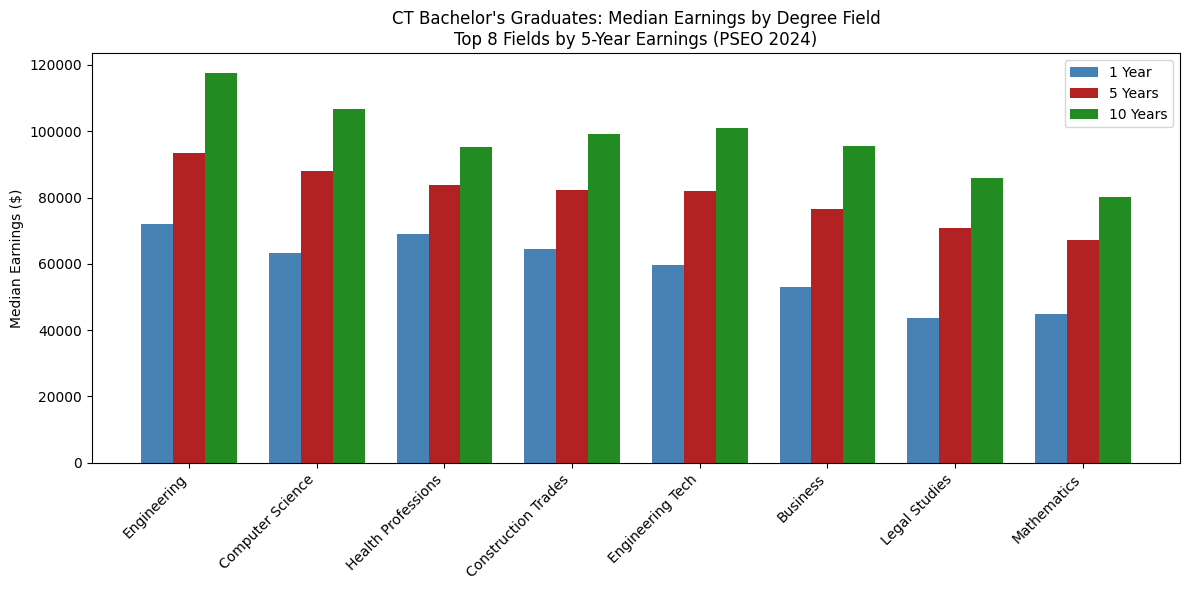

In [15]:
# ---- Figure 2 revised: with real CIP field names ----
cip_names = {
    14: "Engineering",
    11: "Computer Science",
    51: "Health Professions",
    46: "Construction Trades",
    15: "Engineering Tech",
    52: "Business",
    22: "Legal Studies",
    27: "Mathematics"
}

top_fields["field_name"] = top_fields["cipcode"].astype(int).map(cip_names).fillna(top_fields["cipcode"].astype(str))

x = range(len(top_fields))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))
ax.bar([i-0.25 for i in x], top_fields["y1_p50_earnings"], width, label="1 Year", color="steelblue")
ax.bar([i      for i in x], top_fields["y5_p50_earnings"],  width, label="5 Years", color="firebrick")
ax.bar([i+0.25 for i in x], top_fields["y10_p50_earnings"], width, label="10 Years", color="forestgreen")

ax.set_xticks(list(x))
ax.set_xticklabels(top_fields["field_name"], rotation=45, ha="right")
ax.set_ylabel("Median Earnings ($)")
ax.set_title("CT Bachelor's Graduates: Median Earnings by Degree Field\nTop 8 Fields by 5-Year Earnings (PSEO 2024)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_pseo_earnings.png", dpi=150)
plt.show()
